<a href="https://colab.research.google.com/github/d12eek/ANN-And-DL-Lab-24mcs005/blob/main/ANN_And_DL_Lab_1_2_And_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm

#TensorFlow and Keras Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')

# Extra Libraries
import copy
import random
import time

# Linkl to the dataset : https://github.com/ywchiu/riii/blob/master/data/house-prices.csv

In [ ]:
# Path to dataset
dataset_path = "/content/drive/MyDrive/Image_Data"

# Image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.125, 0.125, 0.125])
])

class CatsDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Load all images from the "cats" folder
        cat_folder = os.path.join(root_dir, "Cats")
        for file in os.listdir(cat_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(cat_folder, file))
                self.labels.append(0)  # 0 for Cats

        # Load all images from the "dogs" folder
        dog_folder = os.path.join(root_dir, "Dogs")
        for file in os.listdir(dog_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(dog_folder, file))
                self.labels.append(1)  # 1 for Dogs

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and label
        img_path = self.images[idx]
        label = self.labels[idx]

        # Open image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations if any
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        # Return image and label
        return image, label

# Instantiate Dataset
dataset = CatsDogsDataset(dataset_path, transform=transform)

# DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Test the DataLoader
for images, labels in dataloader:
    print(f"Batch size: {images.shape}, Labels: {labels}")
    break

Batch size: torch.Size([10, 3, 256, 256]), Labels: tensor([0, 0, 0, 1, 0, 0, 1, 1, 1, 1])


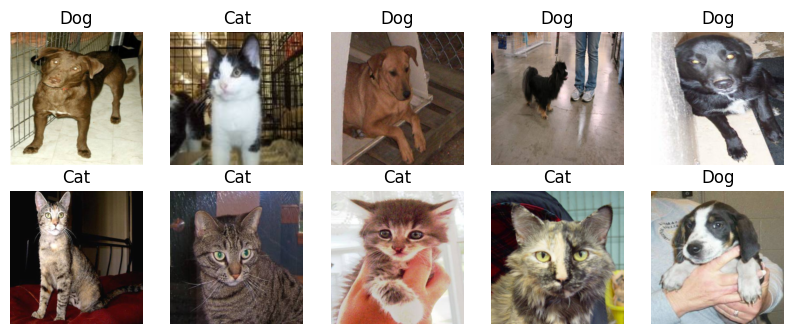

In [ ]:
# Load one batch from DataLoader
images, labels = next(iter(dataloader))

# Define Class Names
class_names = ["Cat", "Dog"]

# Plot the Images
plt.figure(figsize=(10, 10))

# Visualize 25 images (5x5 grid)
for i in range(10):
    plt.subplot(5, 5, i+1)
    img = images[i].permute(1, 2, 0)  # Change tensor shape from (C, H, W) -> (H, W, C)

    # Reverse normalization (optional)
    img = img * 0.125 + 0.5  # Because you normalized with mean=0.5 and std=0.125

    # Plot the image
    plt.imshow(img.numpy())
    plt.title(f"{class_names[labels[i].item()]}")
    plt.axis("off")

plt.show()

Lab 2 :- Deep neural network For Regression

In [ ]:
X_train = np.linspace(-10, 10, 1000)
y_train = np.sin(X_train) + np.random.normal(0, 0.2, size=X_train.shape)

X_test =  np.linspace(-10, 10, 500)
y_test =  np.sin(X_test) + np.random.normal(0, 0.2, size=X_test.shape)

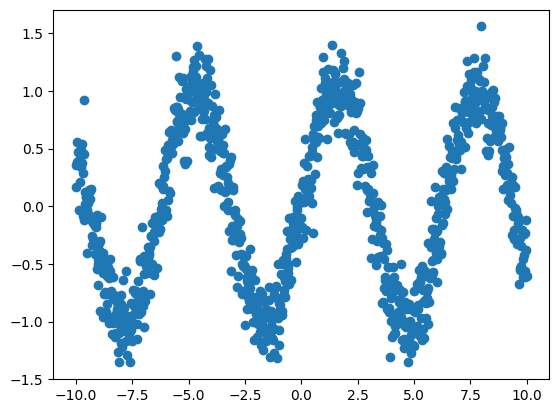

In [ ]:
plt.scatter(X_train, y_train)
plt.show()

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(62, activation='relu', input_dim=1))
model.add(tf.keras.layers.Dense(62, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))

In [ ]:
model.compile(loss='mse', optimizer='adam', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=500)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5731 - mae: 0.6519
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5121 - mae: 0.6199
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4842 - mae: 0.5969
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4869 - mae: 0.5937
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5037 - mae: 0.6166
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5342 - mae: 0.6283
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5287 - mae: 0.6209
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4750 - mae: 0.5834
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4708 - mae: 0.5885
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4951 - mae: 0.6040
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4591 - mae: 0.5666
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4642 - mae: 0.5795
Epoch 13/500
32/32 ━━━━━━━━━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


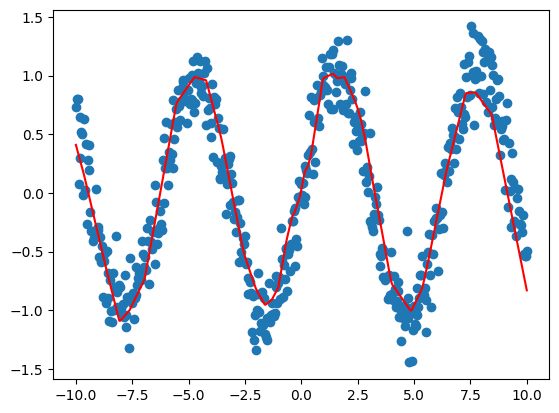

In [ ]:
pred = model.predict(X_test)

plt.scatter(X_test, y_test)
plt.plot(X_test, pred, color='red')
plt.show()

In [ ]:
pred = model.predict(X_test)
print(mean_squared_error(pred, y_test))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
0.05384728082495499


Lab 5 :- CNN For Classification

In [ ]:
for i in images:
  print("Image = ", i.shape)

Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])
Image =  torch.Size([3, 256, 256])


In [ ]:
labels

tensor([1, 0, 1, 1, 1, 0, 0, 0, 0, 1])

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        # Change the input channels of conv1 to 3
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # (B, 3, 256, 256) -> (B, 32, 256, 256)
        self.pool = nn.MaxPool2d(2, 2)                                      # (B, 32, 128, 128)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # (B, 64, 128, 128)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1) # (B, 128, 64, 64)

        # Adjust the input size for fc1
        self.fc1 = nn.Linear(128 * 32 * 32, 256)  # Flatten
        self.fc2 = nn.Linear(256, 2)              # 3 classes: cat, dog, snake

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()  # Because 3 classes
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
device

device(type='cpu')

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")
    print("\nTraining Complete!")

# Train for 5 epochs
train_model(model, dataloader, criterion, optimizer, device, epochs=5)

# Save the trained model
torch.save(model.state_dict(), "cnn_classifier.pth")

Epoch 1/5 | Loss: 0.6944 | Accuracy: 40.00%
Epoch 2/5 | Loss: 0.4002 | Accuracy: 90.00%
Epoch 3/5 | Loss: 3.5820 | Accuracy: 50.00%
Epoch 4/5 | Loss: 3.1953 | Accuracy: 50.00%
Epoch 5/5 | Loss: 0.0001 | Accuracy: 100.00%

Training Complete!


In [ ]:
def test_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"\n🎯 Test Accuracy: {accuracy:.2f}%")

# Testing (on same dataloader because no separate train/test split was mentioned)
test_model(model, dataloader, device)


🎯 Test Accuracy: 90.00%


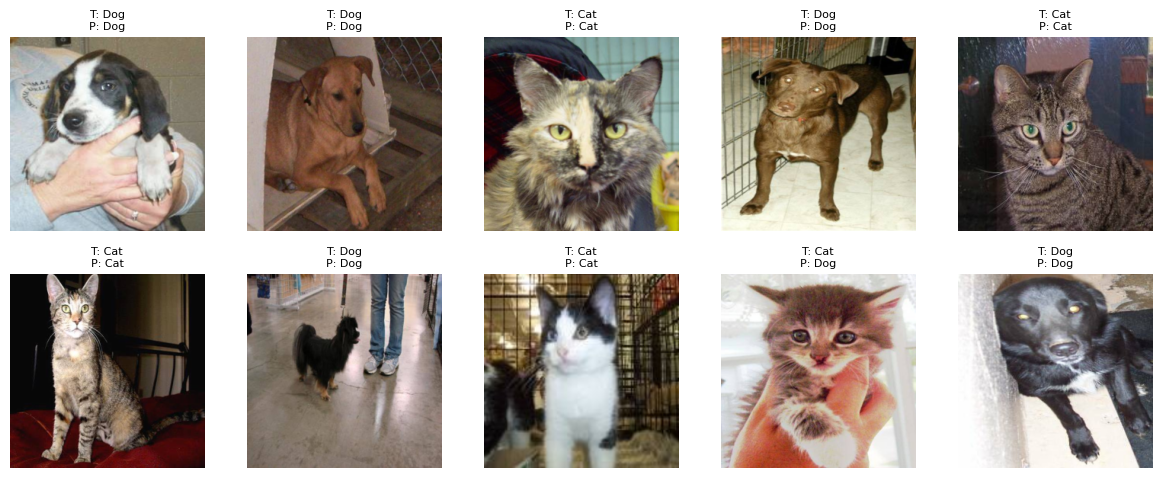

In [ ]:
model.eval()

# Load one batch
images, labels = next(iter(dataloader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 12))
for idx in range(10):
    plt.subplot(5, 5, idx+1)
    img = images[idx].cpu().permute(1, 2, 0)
    img = img * 0.125 + 0.5  # De-normalize
    plt.imshow(img.squeeze(), cmap='gray')
    true_label = class_names[labels[idx].item()]
    pred_label = class_names[preds[idx].item()]
    plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()